# Notebook 05 – XGBoost Machine Learning Model

This notebook trains an XGBoost classifier to predict gentrification pressure levels for Copenhagen neighborhoods.

**Key differences from OLD_05:**
- Target variable: `combined_class_idx` from `classified_combined.gpkg` (0=Low/gentrified, 1=Medium, 2=High)
- Input: GT_V2 only (trend + start/end values + volatility features)
- Future predictions for 2025, 2030, 2035 by linearly extrapolating `_end_value` features using `_reg_2015_2020` slopes

**Note on `first_low_period`:** This temporal field is computed and shown for analysis, but is **excluded from model training** to avoid label leakage (it is non-null only for class-0 clusters, which would perfectly reveal the target).

Predictions are saved in `results/models/`.

## 1. Imports & Configuration

In [20]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

In [21]:
# ── Configuration ────────────────────────────────────────────────────────────

# Paths
FEATURES_PATH       = "../data/raw/GT_V2_data_cph.csv"
COMBINED_GPK_PATH   = "../data/processed/classified_gt/classified_combined.gpkg"
RESULTS_DIR         = "../results/models"

# The 6 historical periods (in order)
PERIODS = ['1990_1995', '1995_2000', '2000_2005', '2005_2010', '2010_2015', '2015_2020']

# Base feature names (19 socio-economic indicators)
BASE_FEATURES = [
    'EMUB', 'PMB', 'PUB', 'age_18_25', 'age_26_40', 'age_41_55', 'age_56_69',
    'crime_main_y', 'disp_inc', 'emp', 'grund', 'gym_erhv', 'lvu',
    'mean_sqm', 'mig_in', 'mig_out', 'ool', 'public_housing', 'unemp'
]

# Future horizons: {year: years_ahead_from_2020}
FUTURE_HORIZONS = {2025: 5, 2030: 10, 2035: 15}

# Ordinal mapping for first_low_period
PERIOD_ORDINAL = {p: i+1 for i, p in enumerate(PERIODS)}  # 1990_1995→1 … 2015_2020→6

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Configuration loaded.")
print("Period ordinal map:", PERIOD_ORDINAL)

Configuration loaded.
Period ordinal map: {'1990_1995': 1, '1995_2000': 2, '2000_2005': 3, '2005_2010': 4, '2010_2015': 5, '2015_2020': 6}


## 2. Load Data

In [22]:
def _ensure_cluster_id(df):
    """Normalize join key to 'cluster_id' regardless of original column name."""
    if 'cluster_id' in df.columns:
        return df
    matches = [c for c in df.columns if c.lower() == 'cluster_id']
    if matches:
        return df.rename(columns={matches[0]: 'cluster_id'})
    heur = [c for c in df.columns if ('cluster' in c.lower()) or ('munic' in c.lower())]
    if heur:
        print(f"INFO: Using '{heur[0]}' as 'cluster_id'")
        return df.rename(columns={heur[0]: 'cluster_id'})
    raise KeyError("No join key found. Expected 'cluster_id' or a column containing 'cluster'/'munic'.")

In [23]:
# Load GT_V2 features
data = pd.read_csv(FEATURES_PATH)
data = _ensure_cluster_id(data)
print(f"GT_V2 features loaded: {data.shape}")
data.head()

GT_V2 features loaded: (1421, 267)


,cluster_id,EMUB_reg_1990_1995,EMUB_reg_1995_2000,EMUB_reg_2000_2005,EMUB_reg_2005_2010,EMUB_reg_2010_2015,EMUB_reg_2015_2020,PMB_reg_1990_1995,PMB_reg_1995_2000,PMB_reg_2000_2005,...,public_housing_std_2000_2005,public_housing_std_2005_2010,public_housing_std_2010_2015,public_housing_std_2015_2020,unemp_std_1990_1995,unemp_std_1995_2000,unemp_std_2000_2005,unemp_std_2005_2010,unemp_std_2010_2015,unemp_std_2015_2020
0,101_1,28.597450,-29.508971,-8.305425,-10.737765,-18.739771,21.651561,1.006311,0.810537,1.273032,...,0.016733,0.024221,0.032863,0.010954,0.970788,0.688128,0.709598,0.880665,0.591041,1.302702
1,101_10,6.118231,-3.252824,3.160862,-1.795472,-7.849762,-7.569549,40.231621,-12.639138,4.562269,...,0.000000,0.000000,0.000000,0.000000,1.479157,1.042160,1.020804,2.021873,0.985894,1.197909
2,101_100,16.270826,-9.405488,1.413428,0.696864,9.424946,-1.370276,-25.301205,17.096774,24.903581,...,0.000000,0.000000,0.000000,0.000000,1.961616,4.803055,2.371906,2.198697,0.801758,0.870205
3,101_1000,18.296847,-0.560272,13.539355,-6.451128,-3.552484,-16.666667,35.381356,101.251956,-20.762053,...,0.000000,0.000000,0.000000,0.000000,2.798931,1.666957,1.241274,1.674763,1.326147,1.771727
4,101_1001,-4.456372,-2.743663,6.824288,-2.665996,3.165375,-4.946775,24.788136,-7.809847,-21.362799,...,0.052440,0.021370,0.013292,0.010954,0.732004,1.315502,0.468931,0.853534,0.415724,0.718192


In [24]:
# Load combined classification GeoPackage (target + first_low_period)
gdf_combined = gpd.read_file(COMBINED_GPK_PATH)
gdf_combined = _ensure_cluster_id(gdf_combined)

# Align cluster_id dtype to string (strip leading zeros / whitespace)
gdf_combined['cluster_id'] = gdf_combined['cluster_id'].astype(str).str.strip().str.lstrip('0')
data['cluster_id'] = data['cluster_id'].astype(str).str.strip().str.lstrip('0')

print(f"classified_combined loaded: {gdf_combined.shape}")
print("Columns:", list(gdf_combined.columns))
gdf_combined[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].head()

classified_combined loaded: (1421, 12)
Columns: ['Shape_Area', 'Shape_Leng', 'cluster_id', 'fid_1', 'id_munic', 'munic_clus', 'munic_code', 'avg_mean', 'combined_class_idx', 'combined_class', 'first_low_period', 'geometry']


,cluster_id,combined_class_idx,combined_class,first_low_period
0,101_1,0,Low,2005_2010
1,101_2,0,Low,2000_2005
2,101_3,0,Low,1990_1995
3,101_4,1,Medium,None
4,101_5,0,Low,2015_2020


In [25]:
# Keep only the columns we need from the GeoPackage
labels = gdf_combined[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].copy()
labels = labels.drop_duplicates('cluster_id')

# Merge into feature data
n_before = len(data)
data = data.merge(labels, on='cluster_id', how='left')
missing_target = data['combined_class_idx'].isna().sum()
print(f"Merged: {len(data)} rows (was {n_before}). Missing target values: {missing_target}")

data[['cluster_id', 'combined_class_idx', 'combined_class', 'first_low_period']].head(10)

Merged: 1421 rows (was 1421). Missing target values: 0


,cluster_id,combined_class_idx,combined_class,first_low_period
0,101_1,0,Low,2005_2010
1,101_10,0,Low,1995_2000
2,101_100,2,High,None
3,101_1000,0,Low,1990_1995
4,101_1001,1,Medium,None
5,101_1002,0,Low,1990_1995
6,101_1003,2,High,None
7,101_1004,0,Low,2015_2020
8,101_1005,1,Medium,None
9,101_1006,0,Low,1995_2000


## 3. Temporality Feature Engineering

`first_low_period` records the earliest period a cluster was classified Low (gentrified). It is encoded as an ordinal integer (1–6) for inspection:
- `'1990_1995'` → 1, `'1995_2000'` → 2, ..., `'2015_2020'` → 6
- `None` / NaN (never classified Low) → 0

> **Important:** `first_low_period_encoded` is added to `data` for analysis purposes only.  
> It is **not included in the training feature matrix X** because it is non-zero exclusively for class-0 clusters, which constitutes label leakage and produces artificially perfect class-0 metrics.

In [26]:
data['first_low_period_encoded'] = (
    data['first_low_period']
    .map(PERIOD_ORDINAL)
    .fillna(0)
    .astype(int)
)

print("first_low_period_encoded distribution:")
print(data.groupby('combined_class_idx')['first_low_period_encoded'].value_counts().sort_index())

first_low_period_encoded distribution:
combined_class_idx  first_low_period_encoded
0                   1                           235
                    2                           210
                    3                           157
                    4                           111
                    5                            88
                    6                            63
1                   0                           299
2                   0                           258
Name: count, dtype: int64


## 4. Define X / y and Train-Val-Test Split

In [27]:
# Drop non-feature columns
DROP_COLS = {'cluster_id', 'combined_class_idx', 'combined_class', 'avg_mean',
             'first_low_period', 'first_low_period_encoded', 'geometry'}

X = data.drop(columns=[c for c in DROP_COLS if c in data.columns])
y = data['combined_class_idx'].astype(int)

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts().sort_index()}")
print(f"\n'first_low_period_encoded' excluded from X (leak prevention): {'first_low_period_encoded' not in X.columns}")

X shape: (1421, 266)
y distribution:
combined_class_idx
0    864
1    299
2    258
Name: count, dtype: int64

'first_low_period_encoded' excluded from X (leak prevention): True


In [28]:
# 60 / 20 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 852, Val: 284, Test: 285


## 5. Hyperparameter Tuning

In [29]:
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.1, 0.2],
    'max_depth':         [3, 6, 9],
    'min_child_weight':  [1, 3, 5],
    'subsample':         [0.7, 0.85, 1.0],
    'colsample_bytree':  [0.7, 0.85, 1.0],
    'reg_alpha':         [0, 0.01, 0.1, 1, 10, 100],
    'reg_lambda':        [0.5, 0.7, 1, 1.3]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=10, scoring='f1_macro', n_iter=100,
    n_jobs=-1, verbose=2, random_state=42
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best hyperparameters:", search.best_params_)
print("Best CV F1-macro:", search.best_score_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best hyperparameters: {'subsample': 0.85, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.85}
Best CV F1-macro: 0.5426535721690737


## 6. Class-Weighted Model (sample_weight)

In [30]:
# Build per-sample weights: balanced by class frequency + optional class-0 boost
classes_arr = np.unique(y_train)
class_weights_arr = compute_class_weight(class_weight='balanced', classes=classes_arr, y=y_train)
class_weight_map = {cls: w for cls, w in zip(classes_arr, class_weights_arr)}

class0_boost = 1.5
if 0 in class_weight_map:
    class_weight_map[0] *= class0_boost

sample_weight = y_train.map(class_weight_map).astype(float).values
print("Class weights (after boost):", class_weight_map)

# Fit weighted model using best hyperparameters
best_params = {k: v for k, v in best_model.get_params().items() if k != 'random_state'}
model_weighted = XGBClassifier(**best_params, random_state=42)
model_weighted.fit(X_train, y_train, sample_weight=sample_weight)
print("Weighted model fitted.")

Class weights (after boost): {np.int64(0): np.float64(0.8223938223938224), np.int64(1): np.float64(1.5865921787709498), np.int64(2): np.float64(1.832258064516129)}
Weighted model fitted.


## 7. Evaluation on Validation and Test Sets


── Validation ──
Accuracy: 0.6479
              precision    recall  f1-score   support

     Low (0)       0.69      0.84      0.76       173
  Medium (1)       0.20      0.10      0.13        60
    High (2)       0.75      0.65      0.69        51

    accuracy                           0.65       284
   macro avg       0.55      0.53      0.53       284
weighted avg       0.60      0.65      0.61       284



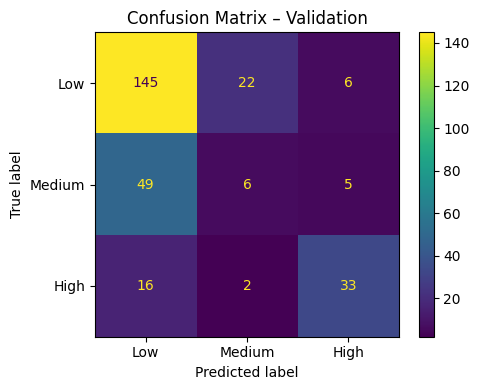


── Test ──
Accuracy: 0.6526
              precision    recall  f1-score   support

     Low (0)       0.72      0.84      0.77       173
  Medium (1)       0.22      0.08      0.12        60
    High (2)       0.60      0.67      0.64        52

    accuracy                           0.65       285
   macro avg       0.51      0.53      0.51       285
weighted avg       0.59      0.65      0.61       285



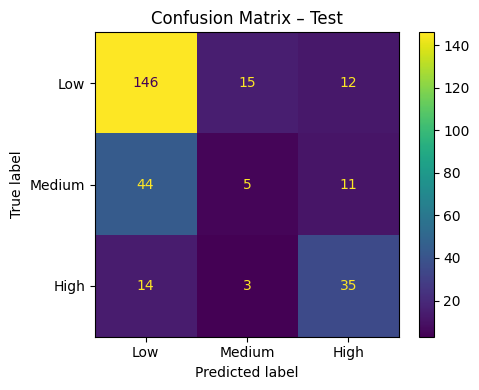

In [31]:
for split_name, X_sp, y_sp in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_pred = model_weighted.predict(X_sp)
    acc = accuracy_score(y_sp, y_pred)
    print(f"\n── {split_name} ──")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_sp, y_pred, target_names=['Low (0)', 'Medium (1)', 'High (2)']))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_sp, y_pred,
        display_labels=['Low', 'Medium', 'High'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix – {split_name}')
    plt.tight_layout()
    plt.show()

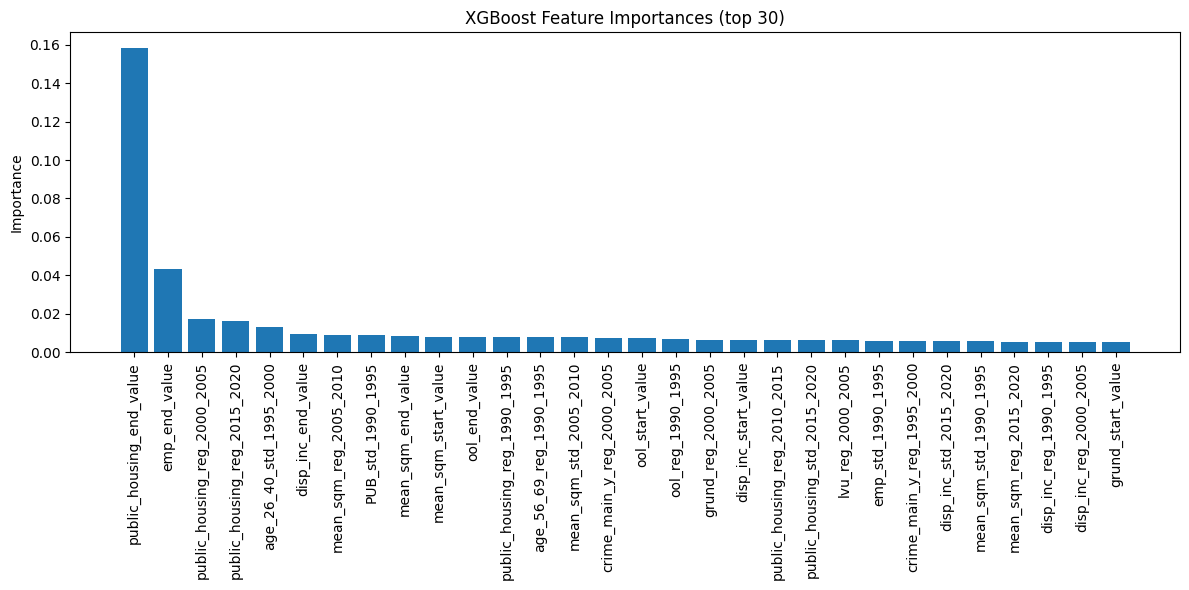

In [32]:
# Feature importance (top 30)
fi = model_weighted.feature_importances_
names = np.array(X.columns)
idx = np.argsort(fi)[::-1][:30]

plt.figure(figsize=(12, 6))
plt.bar(range(len(idx)), fi[idx], align='center')
plt.xticks(range(len(idx)), names[idx], rotation=90)
plt.ylabel('Importance')
plt.title('XGBoost Feature Importances (top 30)')
plt.tight_layout()
plt.show()

## 8. Threshold Tuning for Class 0 (Low / Gentrified)

Auto-selected threshold: 0.100  (Recall0=0.971, Precision0=0.667, F1_0=0.791)


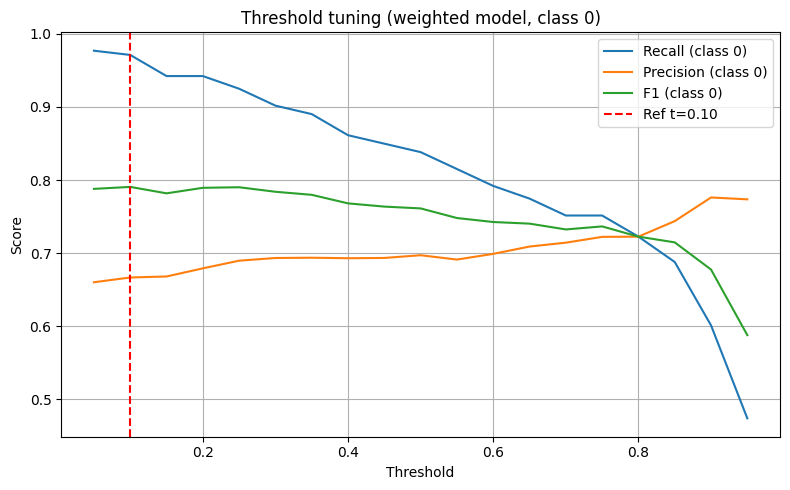

Saved: ../results/models\threshold_tuning_plot.jpg

Using best_t = 0.10 for downstream predictions.


In [38]:
# Binary labels: class 0 is positive
y_val_bin = (y_val == 0).astype(int)
y_test_bin = (y_test == 0).astype(int)

proba_val_all  = model_weighted.predict_proba(X_val)
proba_test_all = model_weighted.predict_proba(X_test)

classes_list = list(getattr(model_weighted, 'classes_', np.array([0, 1, 2])))
idx_class0   = classes_list.index(0) if 0 in classes_list else 0
y_val_prob0  = proba_val_all[:, idx_class0]
y_test_prob0 = proba_test_all[:, idx_class0]

# Sweep thresholds
ts = np.linspace(0.05, 0.95, 19)
recall0s, precision0s, f10s = [], [], []
for t in ts:
    y_pred_bin = (y_val_prob0 >= t).astype(int)
    recall0s.append(recall_score(y_val_bin, y_pred_bin, pos_label=1))
    precision0s.append(precision_score(y_val_bin, y_pred_bin, pos_label=1, zero_division=0))
    f10s.append(f1_score(y_val_bin, y_pred_bin, pos_label=1, zero_division=0))

# Best threshold (F1, tie-break by precision)
best_idx = int(np.argmax(f10s))
candidates = np.where(np.isclose(f10s, f10s[best_idx]))[0]
best_idx = candidates[int(np.argmax([precision0s[i] for i in candidates]))]
ref_t = float(ts[best_idx])

print(f"Auto-selected threshold: {ref_t:.3f}  "
      f"(Recall0={recall0s[best_idx]:.3f}, Precision0={precision0s[best_idx]:.3f}, F1_0={f10s[best_idx]:.3f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ts, recall0s,    label='Recall (class 0)')
ax.plot(ts, precision0s, label='Precision (class 0)')
ax.plot(ts, f10s,        label='F1 (class 0)')
ax.axvline(ref_t, color='red', linestyle='--', label=f'Ref t={ref_t:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold tuning (weighted model, class 0)')
ax.legend(); ax.grid(True)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'threshold_tuning_plot.jpg')
fig.savefig(plot_path, format='jpeg', dpi=300)
plt.show()
print(f"Saved: {plot_path}")

# Final threshold (project choice – override here if needed)
best_t = 0.1
print(f"\nUsing best_t = {best_t:.2f} for downstream predictions.")

Test evaluation at threshold best_t=0.10:
              precision    recall  f1-score   support

     Low (0)       0.68      0.95      0.79       173
  Medium (1)       0.33      0.02      0.03        60
    High (2)       0.64      0.48      0.55        52

    accuracy                           0.67       285
   macro avg       0.55      0.48      0.46       285
weighted avg       0.60      0.67      0.59       285



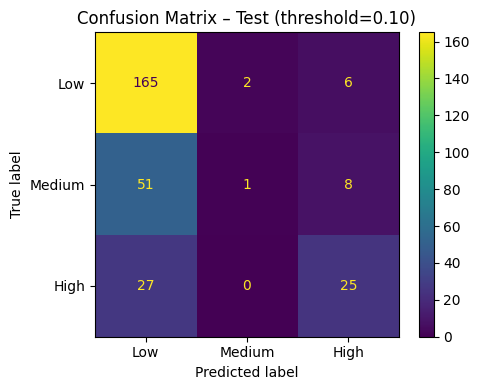

In [39]:
# Multiclass evaluation at tuned threshold
argmax_indices = np.argmax(proba_test_all, axis=1)
argmax_labels  = np.array([classes_list[i] for i in argmax_indices])
y_test_pred_tuned = np.where(y_test_prob0 >= best_t, 0, argmax_labels)

print(f"Test evaluation at threshold best_t={best_t:.2f}:")
print(classification_report(y_test, y_test_pred_tuned, target_names=['Low (0)', 'Medium (1)', 'High (2)']))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred_tuned,
    display_labels=['Low', 'Medium', 'High'], ax=ax
)
ax.set_title(f'Confusion Matrix – Test (threshold={best_t:.2f})')
plt.tight_layout()
plt.show()

## 9. Save 2020 Predictions (Full Dataset)

In [35]:
# Apply tuned threshold to all clusters (not just test set)
proba_all = model_weighted.predict_proba(X)
prob0_all = proba_all[:, idx_class0]
argmax_all = np.array([classes_list[i] for i in np.argmax(proba_all, axis=1)])
pred_all = np.where(prob0_all >= best_t, 0, argmax_all)

pred_df = pd.DataFrame({
    'cluster_id': data.loc[X.index, 'cluster_id'].values,
    'prediction': pred_all
})

out_path = os.path.join(RESULTS_DIR, 'predictions_cph.csv')
pred_df.to_csv(out_path, index=False)
print(f"Saved 2020 predictions: {out_path}  (rows={len(pred_df)})")
print(pred_df['prediction'].value_counts().sort_index())

Saved 2020 predictions: ../results/models\predictions_cph.csv  (rows=1421)
prediction
0    962
1    208
2    251
Name: count, dtype: int64


## 10. Future Predictions: 2025, 2030, 2035

**Strategy:** Linear extrapolation of `{feature}_end_value` using the last-period trend slope `{feature}_reg_2015_2020`.

$$\text{end\_value}_{t} = \text{end\_value}_{2020} + \text{reg\_2015\_2020} \times t$$

where $t$ is the number of years ahead (5, 10, or 15). All other features (trend slopes, std) are held constant as the best available proxy.

In [36]:
def _apply_threshold(model, X_proj, best_t, classes_list, idx_class0):
    """Apply probability threshold rule and return integer class labels."""
    proba = model.predict_proba(X_proj)
    prob0 = proba[:, idx_class0]
    argmax_labels = np.array([classes_list[i] for i in np.argmax(proba, axis=1)])
    return np.where(prob0 >= best_t, 0, argmax_labels)


future_dfs = []

for year, t in FUTURE_HORIZONS.items():
    X_future = X.copy()

    # Extrapolate _end_value for each base feature
    shifted_cols = []
    for feat in BASE_FEATURES:
        end_col  = f'{feat}_end_value'
        reg_col  = f'{feat}_reg_2015_2020'
        if end_col in X_future.columns and reg_col in X_future.columns:
            X_future[end_col] = X_future[end_col] + X_future[reg_col] * t
            shifted_cols.append(end_col)

    print(f"{year}: shifted {len(shifted_cols)} _end_value columns (t={t} years).")

    preds = _apply_threshold(model_weighted, X_future, best_t, classes_list, idx_class0)

    df_fut = pd.DataFrame({
        'cluster_id': data.loc[X.index, 'cluster_id'].values,
        'prediction': preds,
        'year': year
    })

    out_path = os.path.join(RESULTS_DIR, f'future_predictions_{year}.csv')
    df_fut[['cluster_id', 'prediction']].to_csv(out_path, index=False)
    print(f"  Saved: {out_path}")
    print(f"  Class distribution: {dict(pd.Series(preds).value_counts().sort_index())}\n")

    future_dfs.append(df_fut)

print("Future prediction files saved.")

2025: shifted 19 _end_value columns (t=5 years).


  Saved: ../results/models\future_predictions_2025.csv
  Class distribution: {0: np.int64(968), 1: np.int64(205), 2: np.int64(248)}

2030: shifted 19 _end_value columns (t=10 years).
  Saved: ../results/models\future_predictions_2030.csv
  Class distribution: {0: np.int64(971), 1: np.int64(203), 2: np.int64(247)}

2035: shifted 19 _end_value columns (t=15 years).
  Saved: ../results/models\future_predictions_2035.csv
  Class distribution: {0: np.int64(971), 1: np.int64(203), 2: np.int64(247)}

Future prediction files saved.


## 11. Timeline Visualisation

Stacked bar chart showing how the class distribution evolves from 2020 → 2025 → 2030 → 2035.

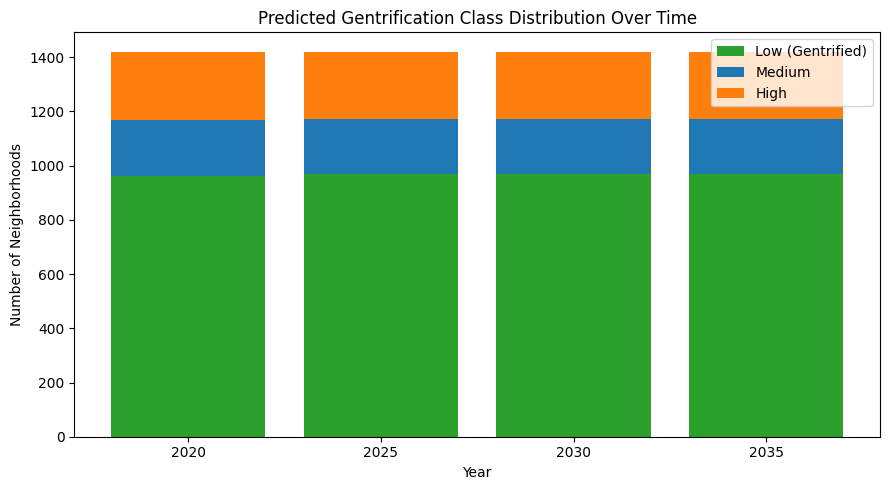

Saved timeline chart: ..\results\figures\gentrification_timeline.jpg

Class counts per year:
prediction  Low (Gentrified)  Medium  High
year                                      
2020                     962     208   251
2025                     968     205   248
2030                     971     203   247
2035                     971     203   247


In [40]:
# Combine 2020 baseline + future predictions
df_2020 = pred_df.copy()
df_2020['year'] = 2020

timeline = pd.concat([df_2020] + future_dfs, ignore_index=True)

# Count per year × class
counts = (
    timeline
    .groupby(['year', 'prediction'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)

# Stacked bar chart
class_labels = {0: 'Low (Gentrified)', 1: 'Medium', 2: 'High'}
colors = {0: '#2ca02c', 1: '#1f77b4', 2: '#ff7f0e'}

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(counts))
x = np.arange(len(counts))

for cls in [0, 1, 2]:
    vals = counts[cls].values if cls in counts.columns else np.zeros(len(counts))
    ax.bar(x, vals, bottom=bottom, label=class_labels[cls], color=colors[cls])
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(counts.index.astype(str))
ax.set_xlabel('Year')
ax.set_ylabel('Number of Neighborhoods')
ax.set_title('Predicted Gentrification Class Distribution Over Time')
ax.legend(loc='upper right')
plt.tight_layout()

fig_path = os.path.join('..', 'results', 'figures', 'gentrification_timeline.jpg')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
fig.savefig(fig_path, format='jpeg', dpi=300)
plt.show()
print(f"Saved timeline chart: {fig_path}")
print("\nClass counts per year:")
print(counts.rename(columns=class_labels))